# Thesis result visualizations

Transparent 3D coronary artery tree meshes loaded from Block 1 outputs (`surface_RCA.vtp`, `surface_LCA.vtp`).

Exports are written to `exports/` next to this notebook and copied to `thesis/TFG_Latex2526/figures/` for inclusion in the report.

## 1. Setup

In [1]:
from __future__ import annotations

import sys
import types
from pathlib import Path

# VTK/PyVista: conda-forge/vmtk builds often omit vtkRenderingMatplotlib.
# Stub it before importing pyvista (same shim as src/blocks/_01_extraction.py).
sys.modules.setdefault(
    "vtkmodules.vtkRenderingMatplotlib",
    types.ModuleType("vtkmodules.vtkRenderingMatplotlib"),
)

import pyvista as pv

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR
while not (PROJECT_ROOT / "src" / "blocks" / "_01_extraction.py").is_file():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise RuntimeError(
            "Could not locate repo root. Start Jupyter from the repo or from "
            "notebooks/results visualizations."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent

BLOCK1_ROOT = PROJECT_ROOT / "results" / "block1_results"
EXPORT_DIR = NOTEBOOK_DIR / "exports"
THESIS_FIG_DIR = PROJECT_ROOT / "thesis" / "TFG_Latex2526" / "figures"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
THESIS_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Prefer static backend in Jupyter; off_screen export still works without a display.
for _backend in ("static", "trame", "client"):
    try:
        pv.set_jupyter_backend(_backend)
        print(f"PyVista Jupyter backend: {_backend}")
        break
    except Exception:
        continue

print(f"Project root : {PROJECT_ROOT}")
print(f"Block 1 root : {BLOCK1_ROOT}")
print(f"Exports      : {EXPORT_DIR}")

PyVista Jupyter backend: static
Project root : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository
Block 1 root : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results
Exports      : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\exports


## 2. Load and render transparent artery tree meshes

In [2]:
from typing import Iterable

import numpy as np

ARTERY_KEYS = ("RCA", "LCA")
ARTERY_COLORS = {
    "RCA": "#6baed6",  # soft blue
    "LCA": "#fc9272",  # soft red
}

MESH_OPACITY = 0.22
WINDOW_SIZE = (1920, 1400)
SCREENSHOT_DPI_SCALE = 1  # window_size already high-res


def load_coronary_surfaces(patient_id: str, block1_root: Path = BLOCK1_ROOT) -> dict[str, pv.PolyData]:
    """Load RCA/LCA smooth surfaces from Block 1 package."""
    sample_dir = block1_root / patient_id
    if not sample_dir.is_dir():
        raise FileNotFoundError(f"Block 1 folder not found: {sample_dir}")

    meshes: dict[str, pv.PolyData] = {}
    missing: list[str] = []
    for artery in ARTERY_KEYS:
        path = sample_dir / f"surface_{artery}.vtp"
        if not path.is_file():
            missing.append(artery)
            continue
        meshes[artery] = pv.read(str(path))

    if missing:
        raise FileNotFoundError(
            f"Missing surface VTP for {patient_id}: {missing}. "
            f"Expected under {sample_dir}/surface_<RCA|LCA>.vtp"
        )
    return meshes


def _combined_bounds(meshes: Iterable[pv.PolyData]) -> np.ndarray:
    mins = []
    maxs = []
    for mesh in meshes:
        b = np.asarray(mesh.bounds, dtype=float)
        mins.append(b[::2])
        maxs.append(b[1::2])
    return np.array([np.min(mins, axis=0), np.max(maxs, axis=0)])


def render_transparent_tree(
    patient_id: str,
    *,
    meshes: dict[str, pv.PolyData] | None = None,
    show_axes: bool = False,
    show_legend: bool = True,
    off_screen: bool = False,
    screenshot_path: Path | None = None,
) -> pv.Plotter:
    """Plot RCA + LCA surfaces with transparency (depth peeling enabled)."""
    if meshes is None:
        meshes = load_coronary_surfaces(patient_id)

    use_off_screen = off_screen or screenshot_path is not None
    plotter = pv.Plotter(
        off_screen=use_off_screen,
        window_size=WINDOW_SIZE,
        title=f"{patient_id} — coronary tree mesh",
    )
    plotter.set_background("white")
    plotter.enable_depth_peeling(number_of_peels=100, occlusion_ratio=0.0)

    for artery in ARTERY_KEYS:
        mesh = meshes[artery]
        plotter.add_mesh(
            mesh,
            color=ARTERY_COLORS[artery],
            opacity=MESH_OPACITY,
            smooth_shading=True,
            show_edges=False,
            name=artery,
            label=artery,
        )

    bmin, bmax = _combined_bounds(meshes.values())
    center = 0.5 * (bmin + bmax)
    span = float(np.max(bmax - bmin))
    if span <= 0:
        span = 1.0

    # Oblique view that shows both arteries (similar to pipeline QC figures).
    plotter.camera_position = [
        center + np.array([1.35 * span, 1.05 * span, 0.85 * span]),
        center,
        (0.0, 0.0, 1.0),
    ]
    plotter.reset_camera_clipping_range()

    if show_axes:
        plotter.add_axes()
    if show_legend:
        plotter.add_legend(size=(0.18, 0.10), bcolor="white", border=True)

    if screenshot_path is not None:
        screenshot_path = Path(screenshot_path)
        screenshot_path.parent.mkdir(parents=True, exist_ok=True)
        plotter.show(screenshot=str(screenshot_path), auto_close=True)
        print(f"Saved: {screenshot_path}")
        return plotter

    return plotter


def export_tree_figure(patient_id: str, *, stem: str | None = None) -> Path:
    """Export PNG to notebook exports/ and thesis figures/."""
    stem = stem or f"fig_artery_tree_mesh_{patient_id}"
    out_nb = EXPORT_DIR / f"{stem}.png"
    out_tex = THESIS_FIG_DIR / f"{stem}.png"

    render_transparent_tree(
        patient_id,
        show_axes=False,
        show_legend=True,
        screenshot_path=out_nb,
    )
    out_tex.write_bytes(out_nb.read_bytes())
    print(f"Copied to thesis figures: {out_tex}")
    return out_nb

## 3. Samples: `Normal_8` (ASOCA) and `MACS_Normal_8` (MACS-18)

Run the next two cells to preview interactively, then export high-resolution PNGs.

In [3]:
PATIENTS = [
    "Normal_8",
    "MACS_Normal_8",
]

for pid in PATIENTS:
    surfaces = load_coronary_surfaces(pid)
    n_pts = sum(m.n_points for m in surfaces.values())
    n_cells = sum(m.n_cells for m in surfaces.values())
    print(f"{pid}: RCA + LCA loaded ({n_pts:,} points, {n_cells:,} cells)")

Normal_8: RCA + LCA loaded (39,830 points, 79,660 cells)
MACS_Normal_8: RCA + LCA loaded (58,472 points, 116,944 cells)


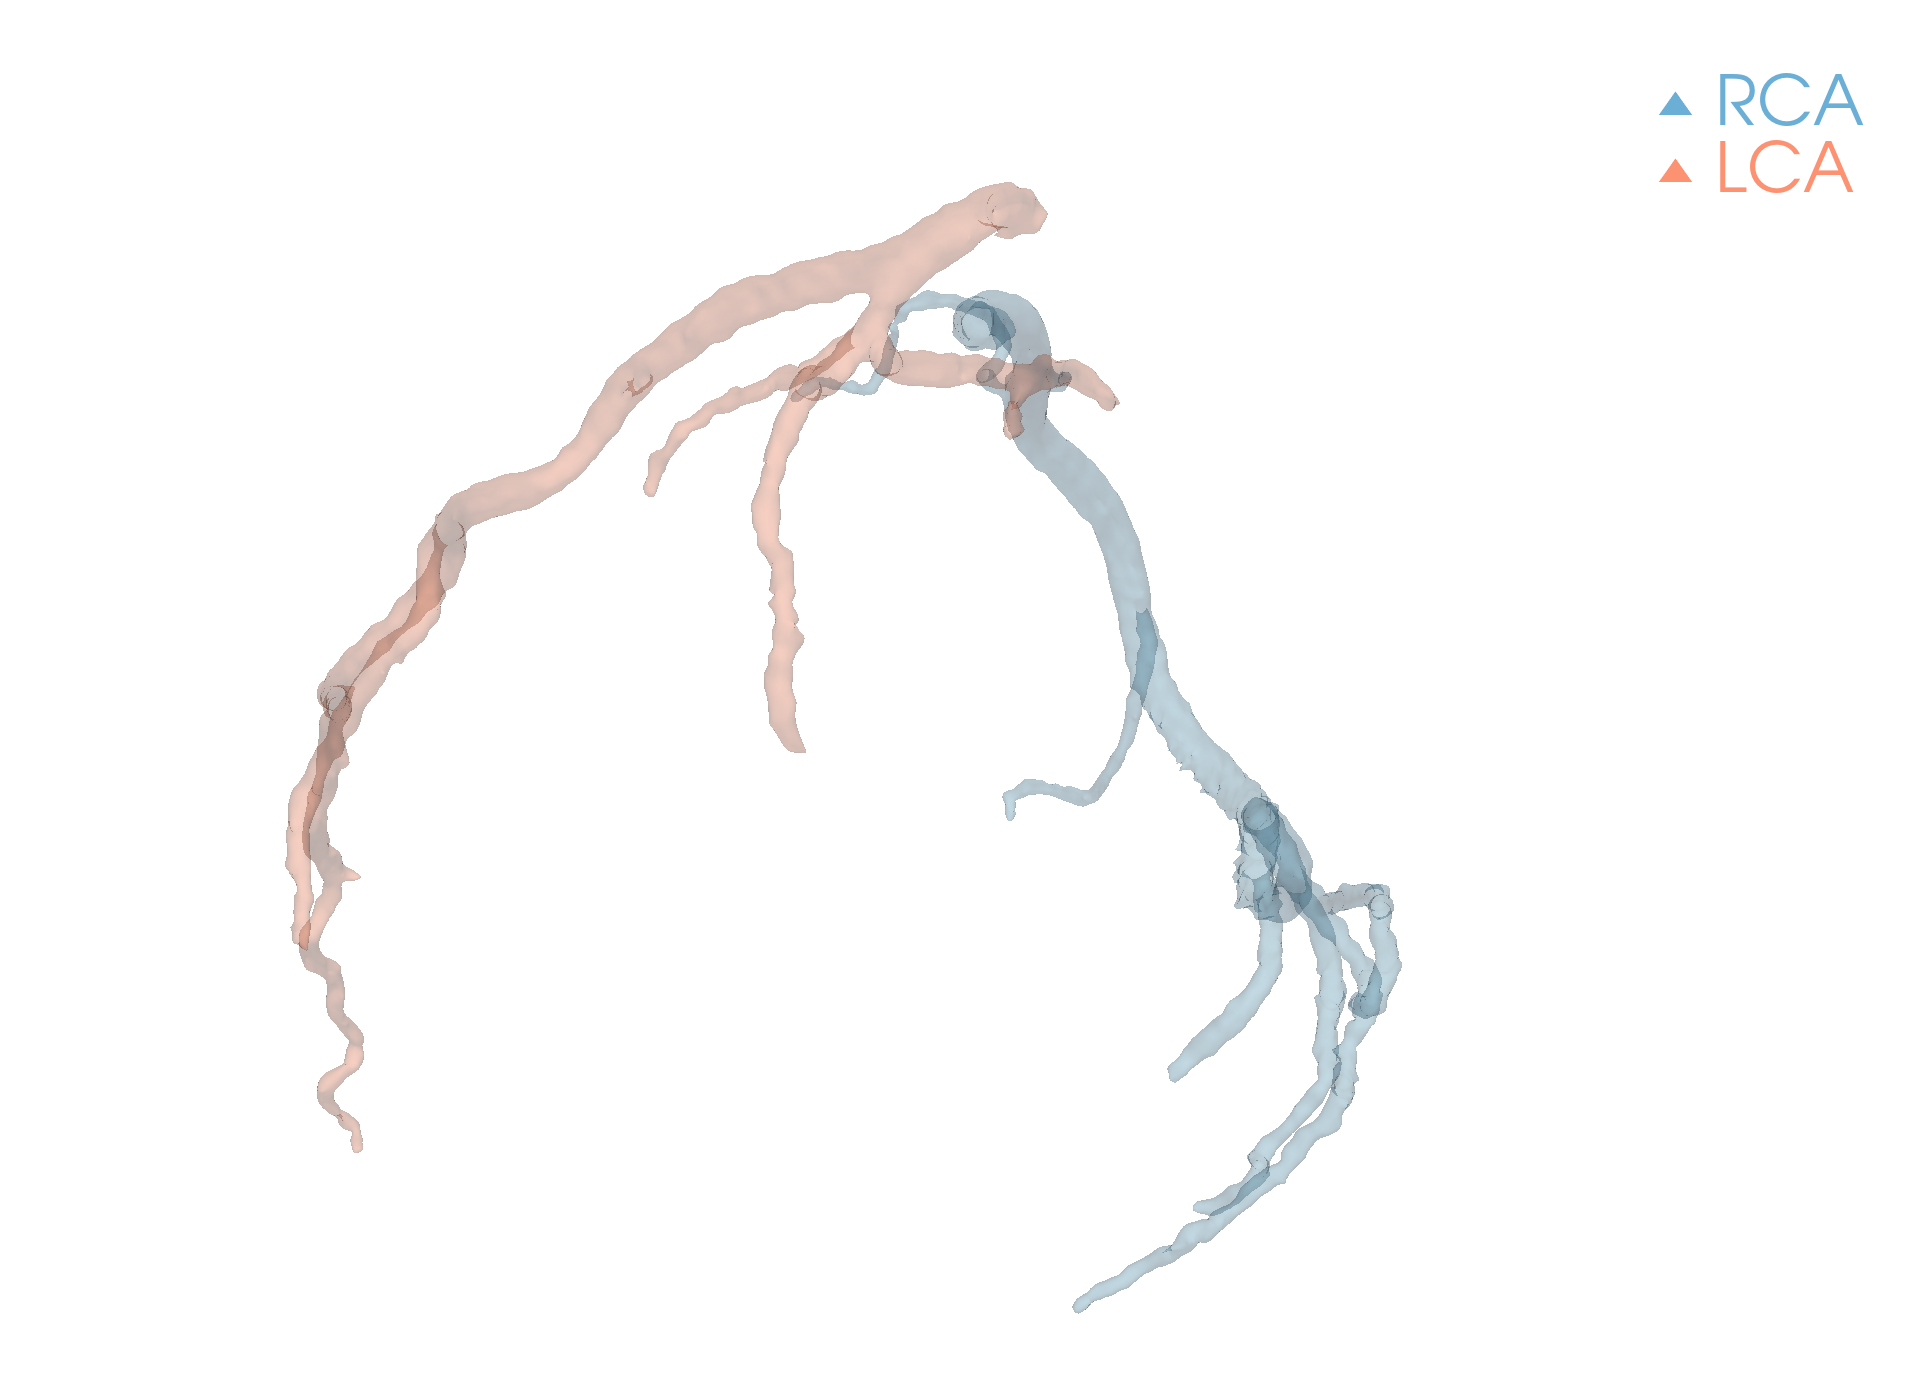

In [4]:
# Interactive preview (one patient per cell — rotate/zoom in the notebook viewer)
patient_id = PATIENTS[0]
pl = render_transparent_tree(patient_id, show_legend=True)
pl.show()

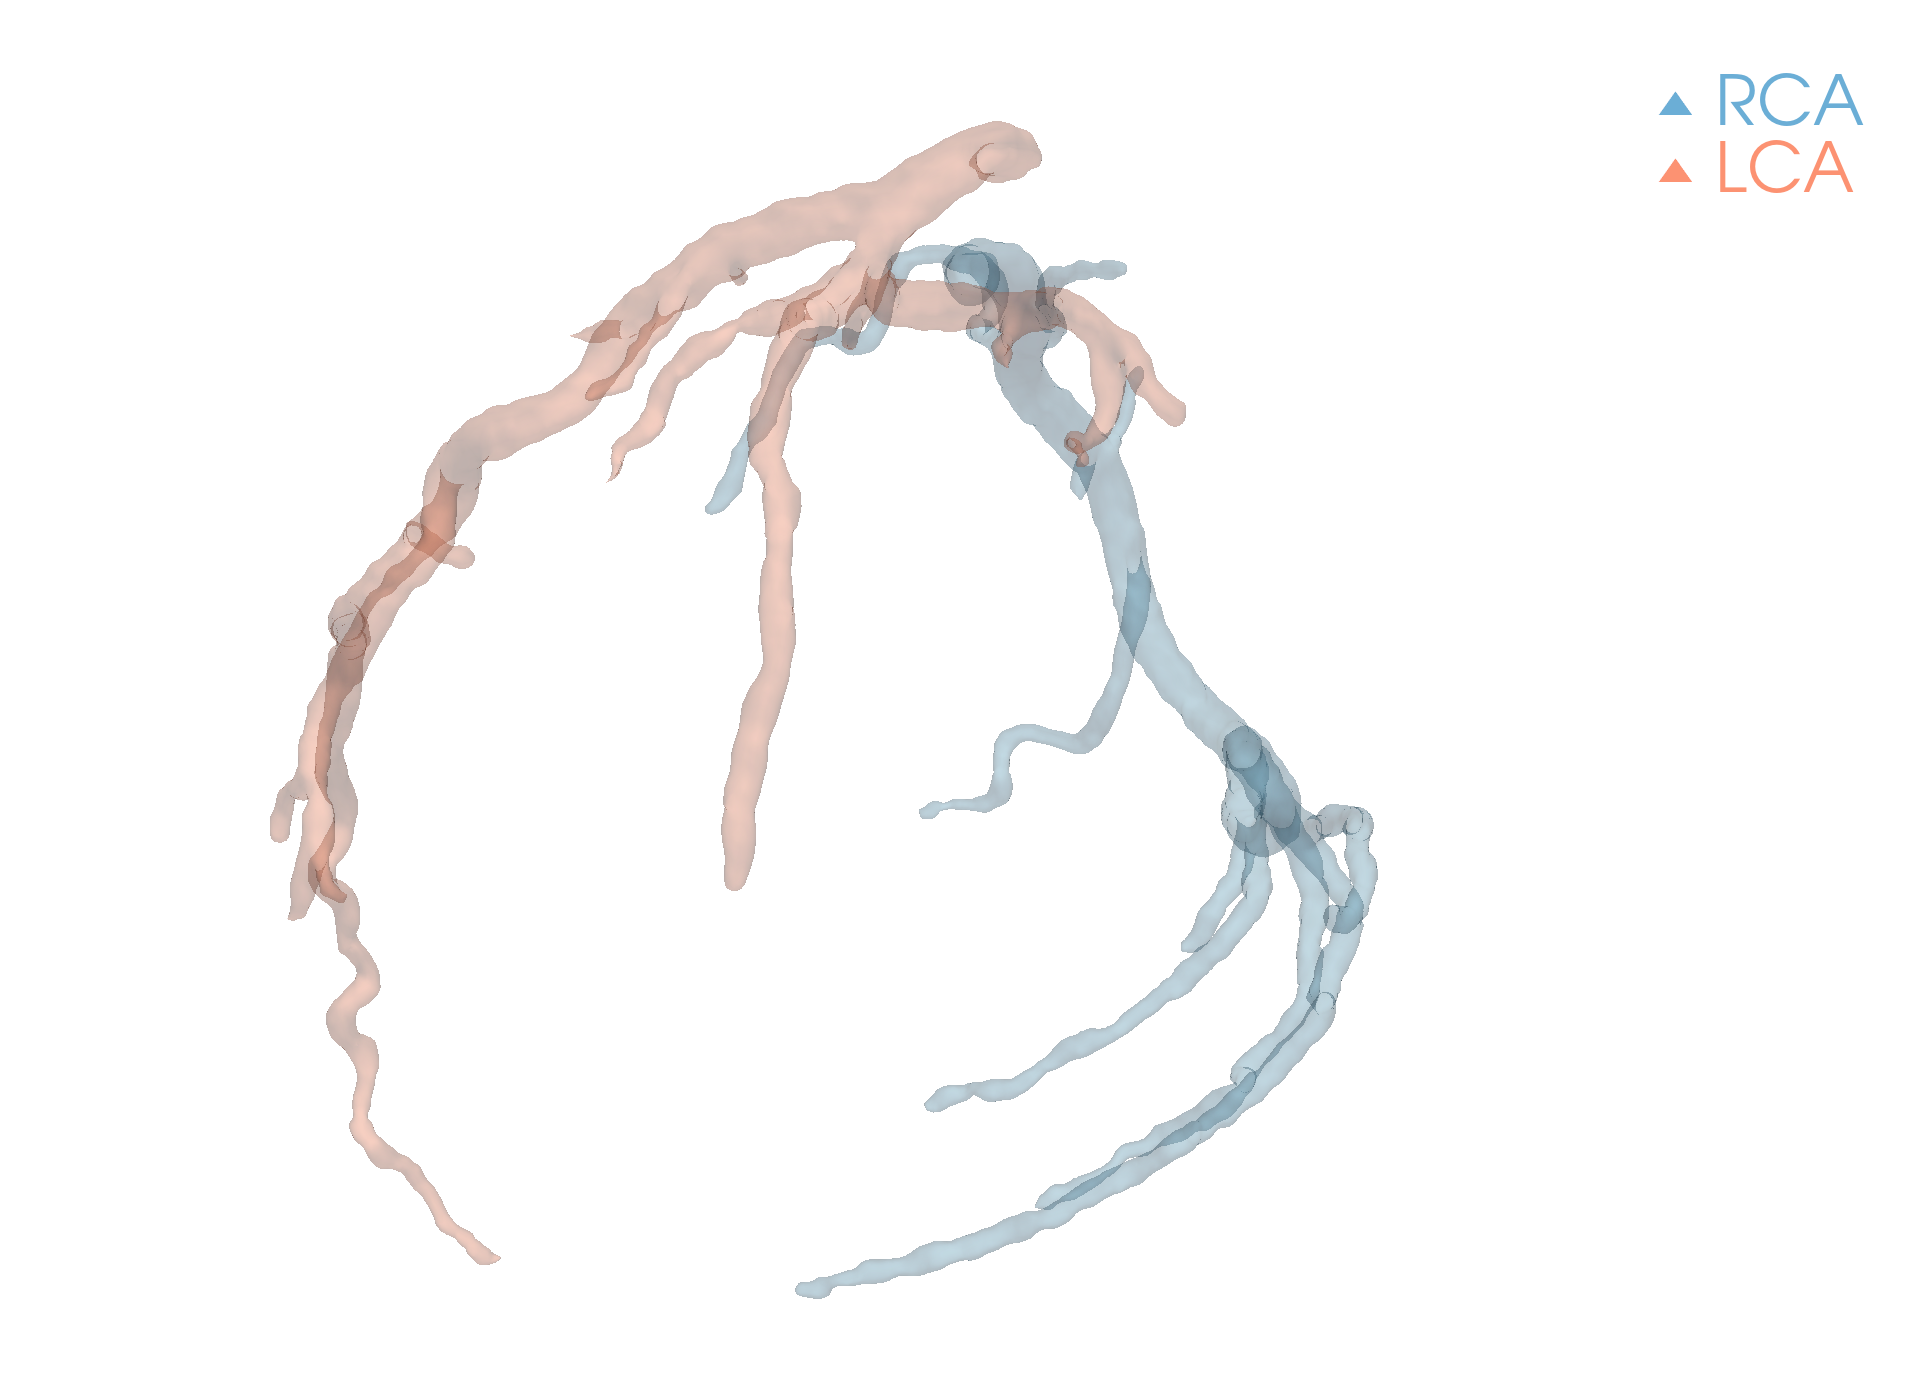

In [5]:
patient_id = PATIENTS[1]
pl = render_transparent_tree(patient_id, show_legend=True)
pl.show()

## 4. Export figures for the thesis

Output files:
- `exports/fig_artery_tree_mesh_Normal_8.png`
- `exports/fig_artery_tree_mesh_MACS_Normal_8.png`

Same files are copied to `thesis/TFG_Latex2526/figures/`.

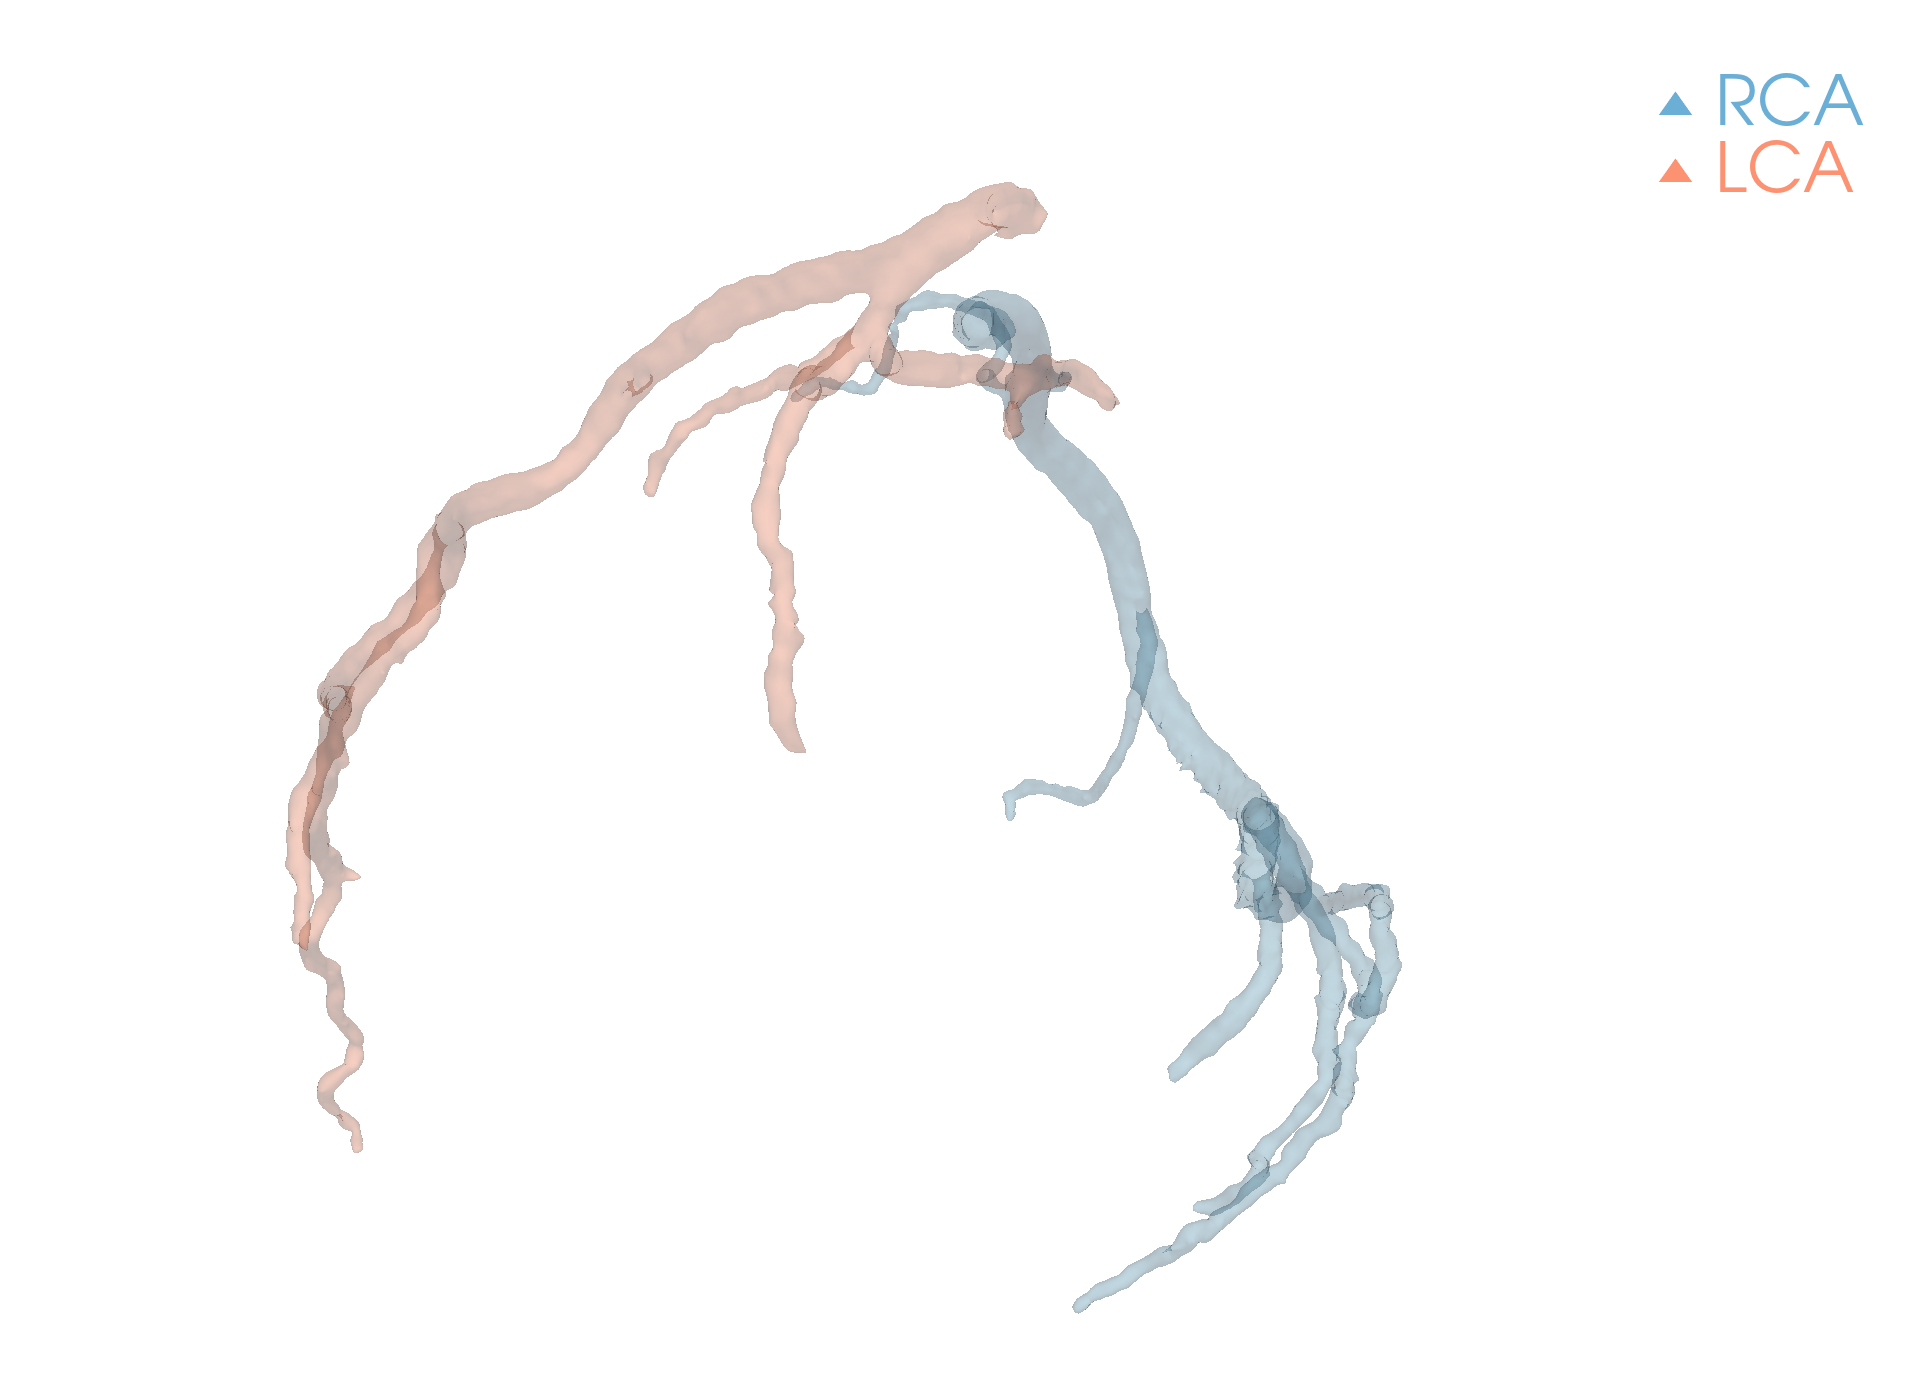

Saved: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\exports\fig_artery_tree_mesh_Normal_8.png
Copied to thesis figures: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\thesis\TFG_Latex2526\figures\fig_artery_tree_mesh_Normal_8.png


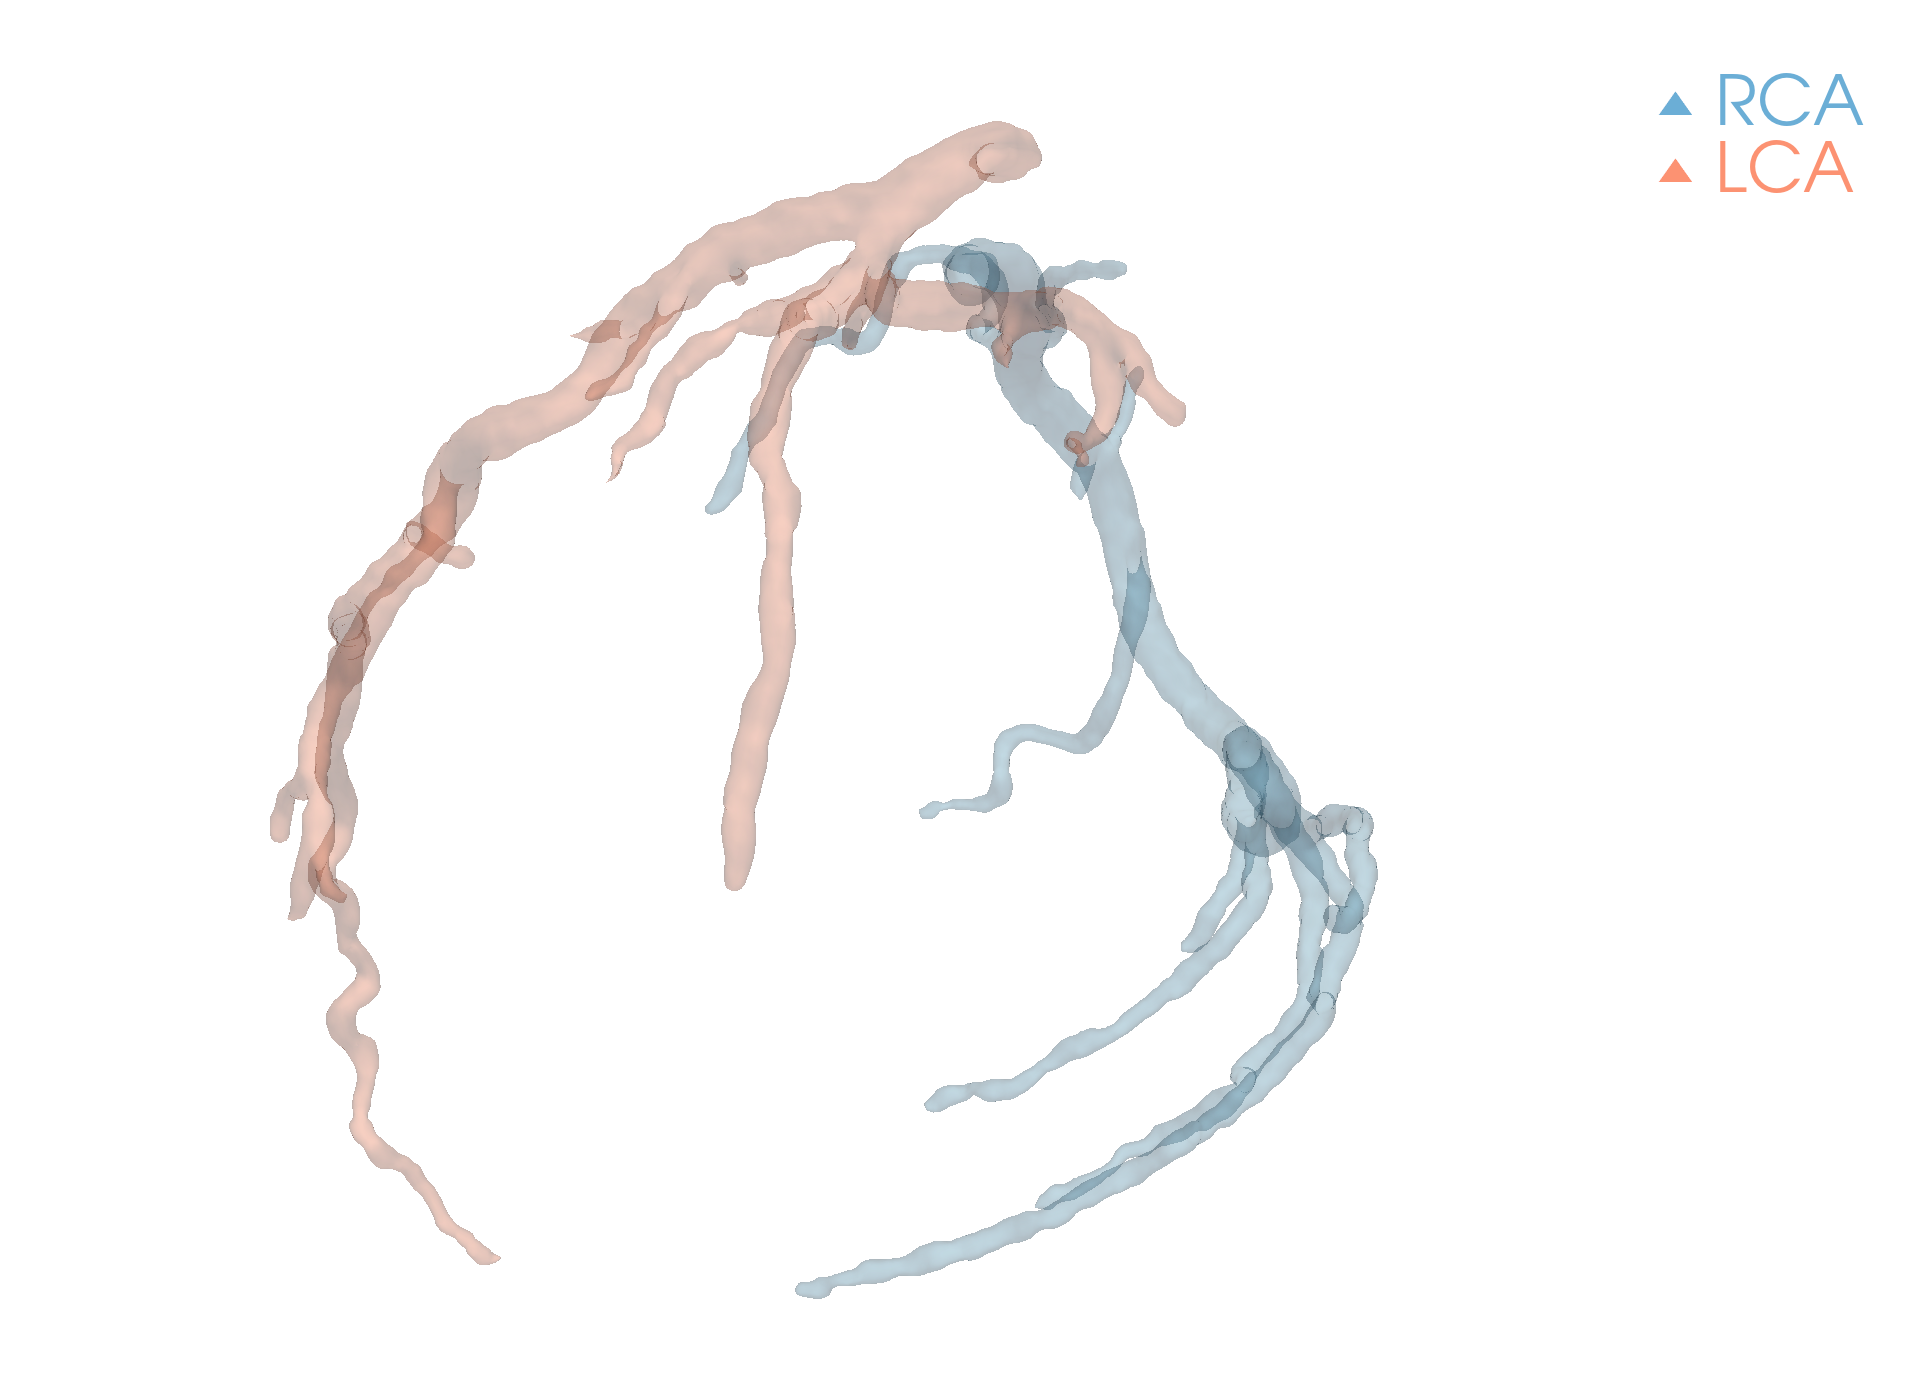

Saved: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\exports\fig_artery_tree_mesh_MACS_Normal_8.png
Copied to thesis figures: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\thesis\TFG_Latex2526\figures\fig_artery_tree_mesh_MACS_Normal_8.png

Exported:
  C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\exports\fig_artery_tree_mesh_Normal_8.png
  C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\exports\fig_artery_tree_mesh_MACS_Normal_8.png


In [6]:
exported: list[Path] = []
for pid in PATIENTS:
    exported.append(export_tree_figure(pid))

print("\nExported:")
for p in exported:
    print(" ", p)